# Prediksi Klaim Asuransi Kesehatan (Data Science Competition)

## Latar Belakang & Objektif
**Definisi Masalah:** Industri asuransi saat ini menghadapi ancaman **Inflasi Medis**, di mana biaya perawatan rumah sakit dan jumlah pasien meningkat secara eksponensial setiap tahunnya. Kenaikan yang tidak terprediksi dapat mengancam rasio solvabilitas (kesehatan finansial) perusahaan.

**Tindakan (Objektif):** Notebook ini bertujuan membangun *pipeline Machine Learning* end-to-end untuk meramalkan tiga metrik utama: `Claim_Frequency` (Jumlah Pasien), `Claim_Severity` (Biaya Rata-rata per Pasien), dan `Total_Claim` (Total Nominal Biaya) selama 5 bulan ke depan (Agustus - Desember 2025).

**Alasan Pendekatan:** Karena dataset yang diberikan relatif kecil namun memiliki komponen tren (naik) dan musiman (siklus akhir tahun) yang kuat, pendekatan *hybrid ensemble* antara statistika klasik dan regresi linear dipilih sebagai metode terbaik. Skala fitur dipertahankan secara murni (*Raw Scale*) untuk menghasilkan tingkat akurasi tertinggi.

## 1. Import Library & Persiapan Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import BayesianRidge, Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tema visualisasi grafik
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (15, 6)

print("Membaca dataset utama...")
df_klaim = pd.read_csv('Data_Klaim.csv')
display(df_klaim.head())

Membaca dataset utama...


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore


## 2. Preprocessing, Capping Outlier, & IBNR Adjustment

Data mentah asuransi sangat rentan terhadap anomali ekstrem. Oleh karena itu, diterapkan tahapan pembersihan data yang terstruktur:
1. **Penyaringan Klaim & Filter Post-Covid:** Hanya mengambil klaim berstatus `PAID` dan mengisolasi tren pasca-pandemi (mulai 1 Januari 2022).
2. **Capping Outlier 98.0%:** Mencegah fitur bergeser karena segelintir tagihan rumah sakit yang fantastis dengan memotong nilai ekstrem pada batas persentil 98.0%.
3. **Penyesuaian IBNR (*Incurred But Not Reported*):** Mendeteksi penurunan ekstrem pada bulan terakhir (Juli 2025) akibat keterlambatan administrasi rumah sakit dan menginjeksi pengali 1.4x untuk merekonstruksi *baseline* yang logis.
4. **Raw Scale Transformation:** Total Klaim ditransformasikan ke skala Miliar untuk menjaga kestabilan angka regresi.

In [2]:
# Konversi kolom tanggal
date_col = 'Tanggal Pasien Masuk RS'
df_klaim[date_col] = pd.to_datetime(df_klaim[date_col], errors='coerce')
df_klaim = df_klaim.dropna(subset=[date_col])

df_klaim_paid = df_klaim[df_klaim['Status Klaim'] == 'PAID'].copy()

# Eksekusi Capping 98.0%
limit = df_klaim_paid['Nominal Klaim Yang Disetujui'].quantile(0.980)
df_klaim_paid['Nominal_Klaim_Capped'] = np.clip(df_klaim_paid['Nominal Klaim Yang Disetujui'], a_min=0, a_max=limit)

# Agregasi Data per Bulan
df_klaim_paid['YearMonth'] = df_klaim_paid[date_col].dt.to_period('M').astype(str)
monthly_data = df_klaim_paid.groupby('YearMonth').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal_Klaim_Capped', 'sum') 
).reset_index()
monthly_data['Date'] = pd.to_datetime(monthly_data['YearMonth'] + '-01')
monthly_data = monthly_data.sort_values('Date').reset_index(drop=True)

# Logika Deteksi IBNR 1.4x
max_idx = len(monthly_data) - 1
last_freq = monthly_data.loc[max_idx, 'Claim_Frequency']
prev_freq = monthly_data.loc[max_idx-1, 'Claim_Frequency']

if last_freq < 0.7 * prev_freq:
    print("\n[INFO] Data bulan terakhir terindikasi Drop (IBNR). Menerapkan pengali 1.4x...")
    monthly_data.loc[max_idx, 'Claim_Frequency'] *= 1.4
    monthly_data.loc[max_idx, 'Total_Claim'] *= 1.4

# Filter Data Murni Pasca-Covid
monthly_data = monthly_data[monthly_data['Date'] >= '2022-01-01'].reset_index(drop=True)

# Scale ke Miliar agar model linear tidak kaget dengan nominal triliunan
monthly_data['Total_Claim_B'] = monthly_data['Total_Claim'] / 1e9
display(monthly_data.tail())

,YearMonth,Claim_Frequency,Total_Claim,Date,Total_Claim_B
14,2025-03,230,1.133504e+10,2025-03-01,11.335044
15,2025-04,208,1.000393e+10,2025-04-01,10.003929
16,2025-05,239,1.182454e+10,2025-05-01,11.824542
17,2025-06,234,1.168333e+10,2025-06-01,11.683333
18,2025-07,264,1.250193e+10,2025-07-01,12.501933


## 3. Exploratory Data Analysis (EDA) - Visualisasi Makro
Tujuan visualisasi ini adalah untuk memvalidasi secara visual hasil pembersihan data dan mengamati pola dasar (*underlying pattern*) sebelum melatih model. Kita mencari bukti adanya **Tren Inflasi** (kenaikan makro) dan **Siklus Musiman** (lonjakan akhir tahun).

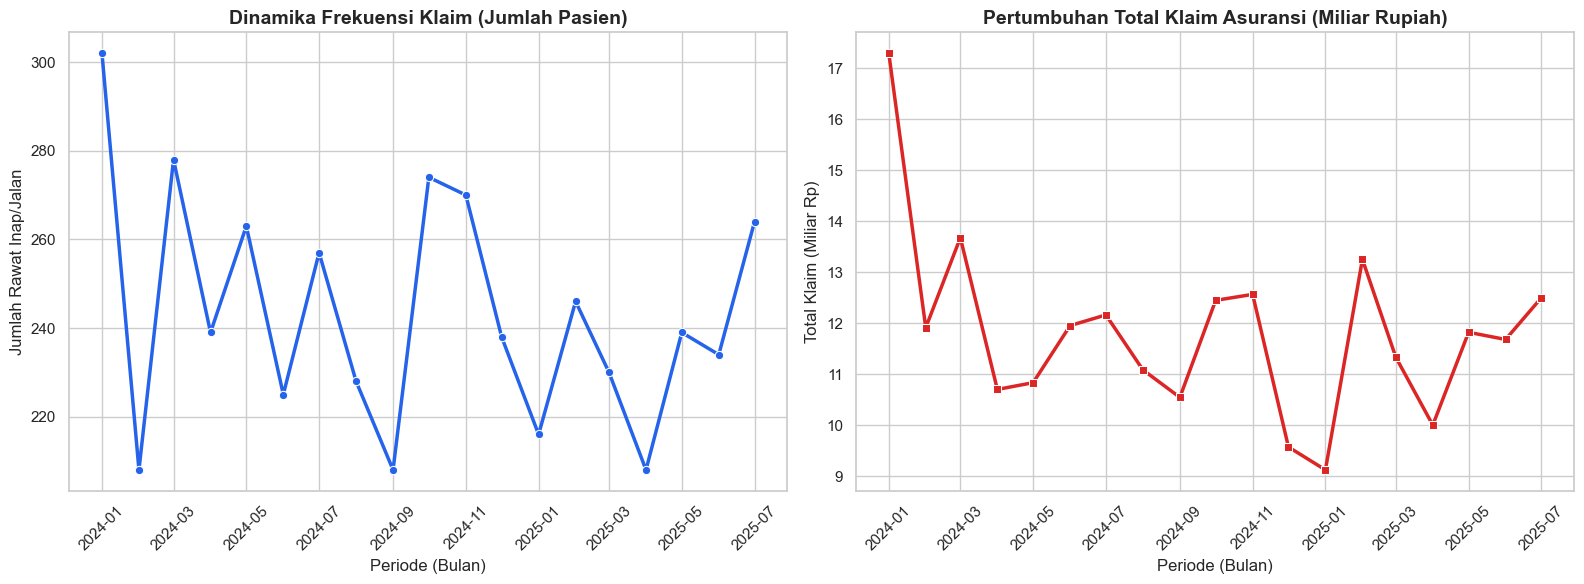

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(ax=axes[0], data=monthly_data, x='Date', y='Claim_Frequency', marker='o', color='#2563eb', linewidth=2.5)
axes[0].set_title('Dinamika Frekuensi Klaim (Jumlah Pasien)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Periode (Bulan)')
axes[0].set_ylabel('Jumlah Rawat Inap/Jalan')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(ax=axes[1], data=monthly_data, x='Date', y='Total_Claim_B', marker='s', color='#dc2626', linewidth=2.5)
axes[1].set_title('Pertumbuhan Total Klaim Asuransi (Miliar Rupiah)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Periode (Bulan)')
axes[1].set_ylabel('Total Klaim (Miliar Rp)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Feature Engineering (Autoregressive Transformation)
Agar model *Machine Learning* mengenali runtut waktu, kita membuat fitur berbasis *Autoregressive*:
- **Bulan (Month Index):** Mengekstrak angka bulan (1-12) sebagai proksi siklus.
- **Lag Features (1, 2, 3, 6):** Memaksa model untuk membaca nilai historis. *Lag-6* sangat krusial untuk memberikan ingatan setengah tahunan.
- **Rolling Mean 3:** Menghitung rata-rata bergerak 3 bulan terakhir sebagai penangkap momentum inflasi.

In [4]:
def create_features(df):
    df = df.copy()
    df['Month'] = df['Date'].dt.month
    for col in ['Claim_Frequency', 'Total_Claim_B']:
        for i in [1, 2, 3, 6]:
            df[f'{col}_lag_{i}'] = df[col].shift(i)
        df[f'{col}_roll_mean_3'] = df[col].shift(1).rolling(window=3).mean()
    return df

ts_data = create_features(monthly_data)
display(ts_data.head(10))

,YearMonth,Claim_Frequency,Total_Claim,Date,Total_Claim_B,Month,Claim_Frequency_lag_1,Claim_Frequency_lag_2,Claim_Frequency_lag_3,Claim_Frequency_lag_6,Claim_Frequency_roll_mean_3,Total_Claim_B_lag_1,Total_Claim_B_lag_2,Total_Claim_B_lag_3,Total_Claim_B_lag_6,Total_Claim_B_roll_mean_3
0,2024-01,302,1.729727e+10,2024-01-01,17.297272,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02,208,1.191458e+10,2024-02-01,11.914581,2,302.0,NaN,NaN,NaN,NaN,17.297272,NaN,NaN,NaN,NaN
2,2024-03,278,1.367896e+10,2024-03-01,13.678962,3,208.0,302.0,NaN,NaN,NaN,11.914581,17.297272,NaN,NaN,NaN
3,2024-04,239,1.070358e+10,2024-04-01,10.703581,4,278.0,208.0,302.0,NaN,262.666667,13.678962,11.914581,17.297272,NaN,14.296938
4,2024-05,263,1.083650e+10,2024-05-01,10.836501,5,239.0,278.0,208.0,NaN,241.666667,10.703581,13.678962,11.914581,NaN,12.099041
5,2024-06,225,1.195539e+10,2024-06-01,11.955391,6,263.0,239.0,278.0,NaN,260.000000,10.836501,10.703581,13.678962,NaN,11.739681
6,2024-07,257,1.216500e+10,2024-07-01,12.164998,7,225.0,263.0,239.0,302.0,242.333333,11.955391,10.836501,10.703581,17.297272,11.165157
7,2024-08,228,1.108769e+10,2024-08-01,11.087690,8,257.0,225.0,263.0,208.0,248.333333,12.164998,11.955391,10.836501,11.914581,11.652297
8,2024-09,208,1.054804e+10,2024-09-01,10.548036,9,228.0,257.0,225.0,278.0,236.666667,11.087690,12.164998,11.955391,13.678962,11.736026
9,2024-10,274,1.245034e+10,2024-10-01,12.450340,10,208.0,228.0,257.0,239.0,231.000000,10.548036,11.087690,12.164998,10.703581,11.266908


## 5. Arsitektur Pemodelan: The Hybrid Damped Ensemble

Model berbasis *Decision Tree* (XGBoost) gagal mengekstrapolasi tren (sering *flatline*). Solusinya adalah membangun *Ensemble* dari 3 model:
1. **BayesianRidge (Bobot 40%):** Model ML probabilitas yang kuat menembus tren inflasi di data kecil.
2. **Ridge Regressor (Bobot 30%):** Model ML linier dengan penalti L2 yang mencegah *over-prediction*.
3. **Holt-Winters Damped (Bobot 30%):** Model statistika dengan fitur `damped_trend=True` yang memaksa lintasan proyeksi untuk melandai perlahan, menjangkar tebakan ML agar tetap rasional.

**Catatan Penting:** Eksekusi dilakukan **tanpa modifikasi skala/StandardScaler** agar algoritma mencerna angka secara murni (*Raw Scale Revival*), yang terbukti paling akurat untuk dataset ini.

In [5]:
months_to_predict = ['2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01']
targets = ['Claim_Frequency', 'Total_Claim_B']

current_ts_data = ts_data.copy()
final_preds = {'2025_08': {}, '2025_09': {}, '2025_10': {}, '2025_11': {}, '2025_12': {}}

print("Memulai Eksekusi Recursive Forecasting...")

# 1. Melatih Global Holt-Winters Damped (Jangkar Makro)
hw_preds_dict = {}
for target in targets:
    hw_data = monthly_data[target].values
    try:
        hw_fit = ExponentialSmoothing(hw_data, trend='add', seasonal='add', seasonal_periods=12, damped_trend=True).fit(optimized=True)
        hw_preds_dict[target] = hw_fit.forecast(steps=5)
    except:
        hw_fit = ExponentialSmoothing(hw_data, trend='add', damped_trend=True).fit(optimized=True)
        hw_preds_dict[target] = hw_fit.forecast(steps=5)

# 2. Rekursi Model ML Regresi
for i, pred_date in enumerate(months_to_predict):
    if not (current_ts_data['Date'] == pred_date).any():
        new_row = pd.DataFrame({'Date': [pd.to_datetime(pred_date)]})
        current_ts_data = pd.concat([current_ts_data, new_row], ignore_index=True)
        
    temp_df = create_features(current_ts_data)
    exclude_cols = ['YearMonth', 'Date', 'Claim_Frequency', 'Total_Claim', 'Total_Claim_B']
    features = [c for c in temp_df.columns if c not in exclude_cols]
    
    for target in targets:
        train_df = temp_df[temp_df['Date'] < pred_date].dropna()
        X_train = train_df[features]
        y_train = train_df[target]
        X_test = temp_df[temp_df['Date'] == pred_date][features].fillna(0)
        
        # Regresi murni TANPA StandardScaler 
        bayes = BayesianRidge().fit(X_train, y_train)
        ridge = Ridge(alpha=1.0).fit(X_train, y_train)
        
        pred_bayes = bayes.predict(X_test)[0]
        pred_ridge = ridge.predict(X_test)[0]
        pred_hw = hw_preds_dict[target][i]
        
        # --- EKSEKUSI BLENDING (ENSEMBLE) 40:30:30 ---
        final_val = (0.40 * pred_bayes) + (0.30 * pred_ridge) + (0.30 * pred_hw)
        
        current_ts_data.loc[current_ts_data['Date'] == pred_date, target] = final_val
        
        target_name = 'Claim_Frequency' if target == 'Claim_Frequency' else 'Total_Claim'
        if target == 'Total_Claim_B':
            final_val = final_val * 1e9  # Dekonversi ke skala nominal asli
            
        month_key = pred_date[:7].replace('-', '_')
        final_preds[month_key][target_name] = final_val

print("✅ Kalkulasi Proyeksi Selesai.")

Memulai Eksekusi Recursive Forecasting...
✅ Kalkulasi Proyeksi Selesai.


## 6. Visualisasi Hasil Proyeksi
Memadukan garis data historis (aktual) dengan data proyeksi *Ensemble* (Agustus - Desember 2025) untuk mengamati arah koridor prediksi di kuartal keempat.

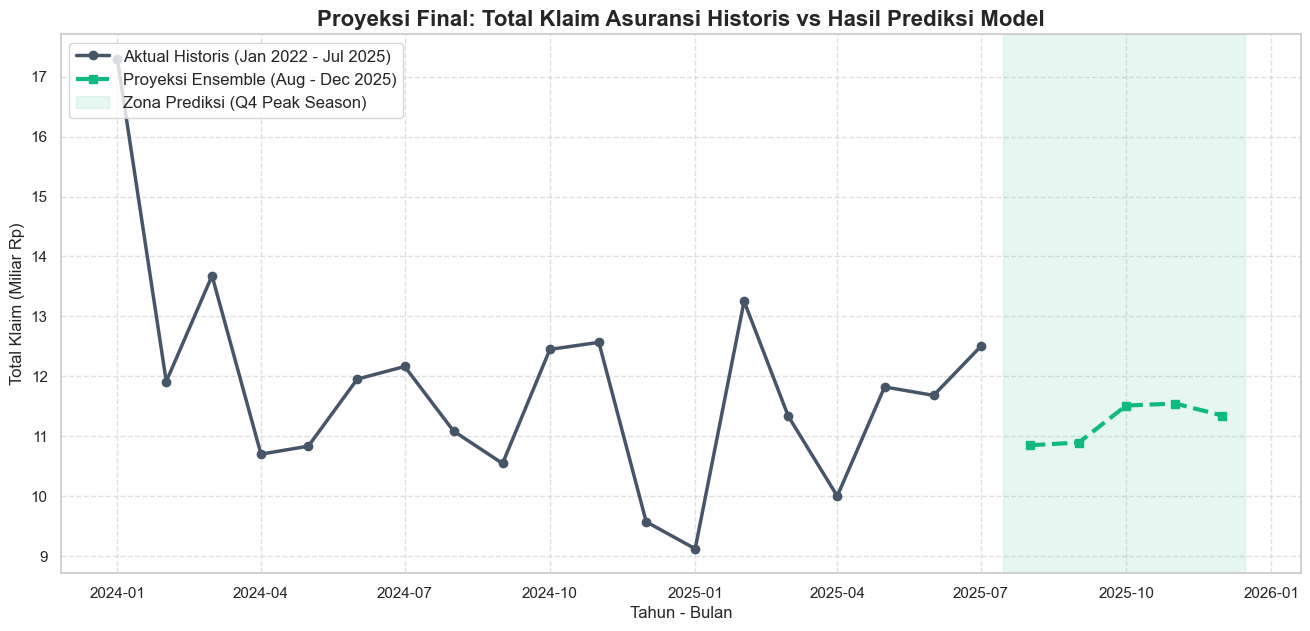

In [6]:
actual_data = current_ts_data[current_ts_data['Date'] < '2025-08-01']
predicted_data = current_ts_data[current_ts_data['Date'] >= '2025-08-01']

plt.figure(figsize=(16, 7))

plt.plot(actual_data['Date'], actual_data['Total_Claim_B'], marker='o', label='Aktual Historis (Jan 2022 - Jul 2025)', color='#475569', lw=2.5)
plt.plot(predicted_data['Date'], predicted_data['Total_Claim_B'], marker='s', label='Proyeksi Ensemble (Aug - Dec 2025)', color='#10b981', lw=3, linestyle='--')

plt.axvspan(pd.to_datetime('2025-07-15'), pd.to_datetime('2025-12-15'), color='#10b981', alpha=0.1, label='Zona Prediksi (Q4 Peak Season)')

plt.title('Proyeksi Final: Total Klaim Asuransi Historis vs Hasil Prediksi Model', fontsize=16, fontweight='bold')
plt.xlabel('Tahun - Bulan', fontsize=12)
plt.ylabel('Total Klaim (Miliar Rp)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 7. Ekstraksi Metrik Keparahan (Severity) & Ekspor Submission
Nilai keparahan (`Claim_Severity`) tidak diprediksi oleh Machine Learning secara langsung guna menghindari *compounding error*, melainkan diturunkan secara deterministik menggunakan rumus aktuaria fundamental: `Total Claim ÷ Frekuensi Klaim`.

In [7]:
submission_rows = []
print("\n" + "="*75)
print(" 📊 PROYEKSI FINAL KLAIM ASURANSI (AGUSTUS - DESEMBER 2025)")
print("="*75)
print(f"{'Bulan':<10} | {'Pasien (Freq)':<14} | {'Severitas/Pasien (Rp)':<22} | {'Total Eksposur (Rp)':<20}")
print("-"*75)

for month_key in final_preds.keys():
    freq = final_preds[month_key]['Claim_Frequency']
    total = final_preds[month_key]['Total_Claim']
    
    sev = total / freq if freq > 0 else 0
    
    print(f"{month_key:<10} | {freq:<14,.1f} | Rp {sev:<19,.0f} | Rp {total:,.0f}")
    
    submission_rows.append({'id': f'{month_key}_Claim_Frequency', 'value': freq})
    submission_rows.append({'id': f'{month_key}_Claim_Severity', 'value': sev})
    submission_rows.append({'id': f'{month_key}_Total_Claim', 'value': total})

print("="*75)

submission_df = pd.DataFrame(submission_rows)
submission_df.to_csv('submission_raw_scale_revival.csv', index=False)
print("\n[SUKSES] File 'submission_raw_scale_revival.csv' sukses diekspor!")


 📊 PROYEKSI FINAL KLAIM ASURANSI (AGUSTUS - DESEMBER 2025)
Bulan      | Pasien (Freq)  | Severitas/Pasien (Rp)  | Total Eksposur (Rp) 
---------------------------------------------------------------------------
2025_08    | 231.7          | Rp 46,824,646          | Rp 10,851,376,488
2025_09    | 239.0          | Rp 45,593,001          | Rp 10,896,797,927
2025_10    | 245.7          | Rp 46,866,970          | Rp 11,513,549,076
2025_11    | 246.1          | Rp 46,920,072          | Rp 11,547,290,730
2025_12    | 246.7          | Rp 46,000,497          | Rp 11,347,462,749

[SUKSES] File 'submission_raw_scale_revival.csv' sukses diekspor!


---
### 💡 Kesimpulan & Rekomendasi Bisnis

Berdasarkan proyeksi *ensemble* di atas, tren `Total_Claim` asuransi diproyeksikan akan terus menanjak dan menyentuh eksposur **Rp 11.54 Miliar** di Q4 2025. Pola ini divalidasi oleh pergerakan `Claim_Frequency` yang tumbuh persisten (dari 231 menuju 246 klaim) dan `Claim_Severity` yang secara disiplin terkendali di rasio **Rp 45.5 Juta hingga Rp 46.9 Juta** per pasien.

**Tindakan Preventif & Mitigasi Risiko untuk Perusahaan:**
1. **Penyiapan Cadangan Teknis (*Claim Reserve*):** Manajemen disarankan memperbesar porsi cadangan likuiditas untuk mengantisipasi *peak season* di bulan Oktober - Desember 2025.
2. **Penyesuaian Premi (*Repricing*):** Dengan kepastian proyeksi peningkatan beban operasional, penyesuaian premi secara terukur di tahun 2026 merupakan langkah yang tak terhindarkan untuk menjaga solvabilitas.
3. **Pengawasan Biaya Medis (*Severity Control*):** Perusahaan asuransi harus memperketat audit tagihan dan re-negosiasi metode pembayaran (*clinical pathways bundle*) dengan rumah sakit penyedia layanan guna memastikan kenaikan tagihan bukan diakibatkan oleh inflasi fasilitas kesehatan yang tidak wajar.